# Análisis CLV completo — BG/NBD + Gamma-Gamma

Notebook principal del TFM. Integra los dos modelos del marco BTYD bayesiano y produce las estimaciones de CLV que constituyen el resultado principal del trabajo. Sigue literalmente la API y el flujo de trabajo recomendados en:

- **PyMC-Marketing — BG/NBD Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/bg_nbd.html
- **PyMC-Marketing — Gamma-Gamma Model:** https://www.pymc-marketing.io/en/stable/notebooks/clv/gamma_gamma.html

## Esquema conceptual

El CLV se descompone en dos factores independientes:

$$
\mathrm{CLV}_i(t) \;=\; \underbrace{\mathbb{E}[X_i(t) \mid \text{historial}]}_{\text{BG/NBD: transacciones futuras}} \;\times\; \underbrace{\mathbb{E}[\bar{Z}_i \mid \text{historial}]}_{\text{Gamma-Gamma: valor por transacción}}
$$

El modelo BG/NBD aporta las transacciones futuras esperadas y $P(\text{vivo})$; el Gamma-Gamma aporta el gasto medio por transacción condicionado a ser usuario recurrente. La independencia de los dos componentes —que es un supuesto formal del modelo Gamma-Gamma— se valida verificando que la correlación de Pearson entre `frequency` y `monetary_value` sea baja.

## Estructura del notebook

1. Carga del dataset y particiones
2. Ajuste del **BG/NBD** + diagnósticos + PPC
3. Ajuste del **Gamma-Gamma** + diagnósticos
4. **Predicciones individuales**: $P(\text{vivo})$, transacciones esperadas, gasto esperado
5. **CLV** a 1, 3 y 5 años con intervalos de credibilidad
6. **Segmentación**: CLV por tipo de título, cohorte y subpoblación joven
7. Conclusiones

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import xarray as xr
from pymc_marketing import clv

from config import (
    SEED, STATS, PARAMS_CALIBRATED, PRIORS, PRIORS_DEFAULT_KEY,
    MCMC_CONFIG, RFM_PATH, priors_to_model_config,
)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
sns.set_palette("deep")

RNG = np.random.default_rng(SEED)

# Precio medio del viaje (€) — sirve para convertir CLV en "viajes esperados"
# a CLV en euros. Valor de referencia: 0.66 €/viaje en el sistema CTAGR.
PRECIO_VIAJE = 0.66

print(f"arviz {az.__version__}")
print(f"Prior por defecto:    {PRIORS_DEFAULT_KEY}")
print(f"Configuración MCMC:   {MCMC_CONFIG}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


arviz 0.23.4
Prior por defecto:    weakly_informative
Configuración MCMC:   {'draws': 2000, 'tune': 1500, 'chains': 4, 'target_accept': 0.9, 'nuts_sampler': 'nutpie', 'progressbar': True, 'random_seed': 42}


## 1. Carga del dataset y particiones

El Gamma-Gamma requiere usuarios con `frequency > 0` (al menos una transacción repetida). El BG/NBD admite todos. Trabajaremos con dos vistas del dataset:

- **`data_full`** — todos los usuarios. Entrada al BG/NBD.
- **`data_recurring`** — sólo usuarios con $x > 0$. Entrada al Gamma-Gamma.

Antes de pasar al Gamma-Gamma comprobamos un supuesto clave del modelo: que la correlación entre frequency y monetary_value sea baja (la referencia oficial usa el umbral $\approx 0.11$).

In [2]:
rfm = pd.read_csv(RFM_PATH)

data_full = rfm[["customer_id", "frequency", "recency", "T", "monetary_value"]].copy()
data_recurring = data_full.query("frequency > 0").copy()

print(f"Dataset cargado desde: {RFM_PATH}")
print(f"  Usuarios totales:        {len(data_full):,}")
print(f"  Usuarios recurrentes:    {len(data_recurring):,}  ({100*len(data_recurring)/len(data_full):.1f} %)")

# Verificación del supuesto Gamma-Gamma: correlación frequency / monetary baja
corr = data_recurring[["frequency", "monetary_value"]].corr().iloc[0, 1]
umbral = 0.30
estado = "✓" if abs(corr) < umbral else "✗"
print(f"\nSupuesto Gamma-Gamma — independencia frequency vs monetary:")
print(f"  Correlación de Pearson: {corr:+.3f}  (umbral aceptable: |ρ| < {umbral})  {estado}")

Dataset cargado desde: C:\Users\andre\OneDrive\Documentos\UGR\tfm-clv-transporte-granada\data\synthetic\rfm_full.csv
  Usuarios totales:        59,995
  Usuarios recurrentes:    59,123  (98.5 %)

Supuesto Gamma-Gamma — independencia frequency vs monetary:
  Correlación de Pearson: -0.129  (umbral aceptable: |ρ| < 0.3)  ✓


## 2. Modelo BG/NBD

### Recordatorio matemático

Mientras el usuario está "vivo" sus validaciones siguen un Poisson con tasa $\lambda_i$; tras cada período activo abandona con probabilidad $p_i$. La heterogeneidad poblacional es:

$$
\lambda_i \sim \mathrm{Gamma}(r,\, \alpha), \qquad p_i \sim \mathrm{Beta}(a,\, b)
$$

La verosimilitud individual para un usuario con historial $(x, t_x, T)$ es la suma compacta de Fader-Hardie-Lee (2005). `pymc-marketing` la implementa internamente.

Los priors se eligen desde `config.PRIORS[PRIORS_DEFAULT_KEY]` — para que cambiar el juego de priors sea un único edit en `config.py`.

In [ ]:
bgnbd = clv.BetaGeoModel(
    data=data_full,
    model_config=priors_to_model_config(PRIORS[PRIORS_DEFAULT_KEY])
)
bgnbd.build_model()
print("Modelo BG/NBD construido")
print(bgnbd)

Modelo BG/NBD construido
BG/NBD
            alpha ~ Weibull(2, 10)
      phi_dropout ~ Uniform(0, 1)
    kappa_dropout ~ Pareto(1, 1)
                r ~ Weibull(2, 1)
                a ~ Deterministic(f(kappa_dropout, phi_dropout))
                b ~ Deterministic(f(kappa_dropout, phi_dropout))
recency_frequency ~ BetaGeoNBD(a, b, r, alpha, <constant>)


In [4]:
print(f"Ajustando BG/NBD sobre {len(data_full):,} usuarios con NUTS (nutpie)...")
t0 = time.time()
bgnbd.fit(**MCMC_CONFIG)
print(f"Fit completo en {(time.time()-t0)/60:.1f} minutos")

Ajustando BG/NBD sobre 59,995 usuarios con NUTS (nutpie)...


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3500,0,0.30,31
,3500,0,0.30,3
,3500,0,0.31,31
,3500,0,0.32,3


Fit completo en 26.7 minutos


In [5]:
VARS_BG = ["r", "alpha", "a", "b"]
summary_bg = az.summary(bgnbd.idata, var_names=VARS_BG, hdi_prob=0.95, round_to=4)
print("Resumen posterior BG/NBD (HDI 95 %):")
print(summary_bg)

# Diagnósticos
n_div = int(bgnbd.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div}  {'✓' if n_div == 0 else '✗'}")
print("R̂:", "✓" if (summary_bg["r_hat"] < 1.01).all() else "✗")
print("ESS_bulk > 400:", "✓" if (summary_bg["ess_bulk"] > 400).all() else "✗")

Resumen posterior BG/NBD (HDI 95 %):
          mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
r      12.9657  0.0966   12.7800    13.1563     0.0024   0.0016  1569.3975   
alpha  13.9865  0.1062   13.7768    14.1961     0.0027   0.0018  1537.4495   
a       0.2688  0.0029    0.2630     0.2744     0.0000   0.0000  3827.1780   
b      19.2242  0.4099   18.4384    20.0333     0.0081   0.0061  2547.1763   

        ess_tail   r_hat  
r      2106.1193  1.0031  
alpha  2032.7923  1.0033  
a      5006.6722  1.0001  
b      2564.8182  1.0004  

Divergencias: 0  ✓
R̂: ✓
ESS_bulk > 400: ✓


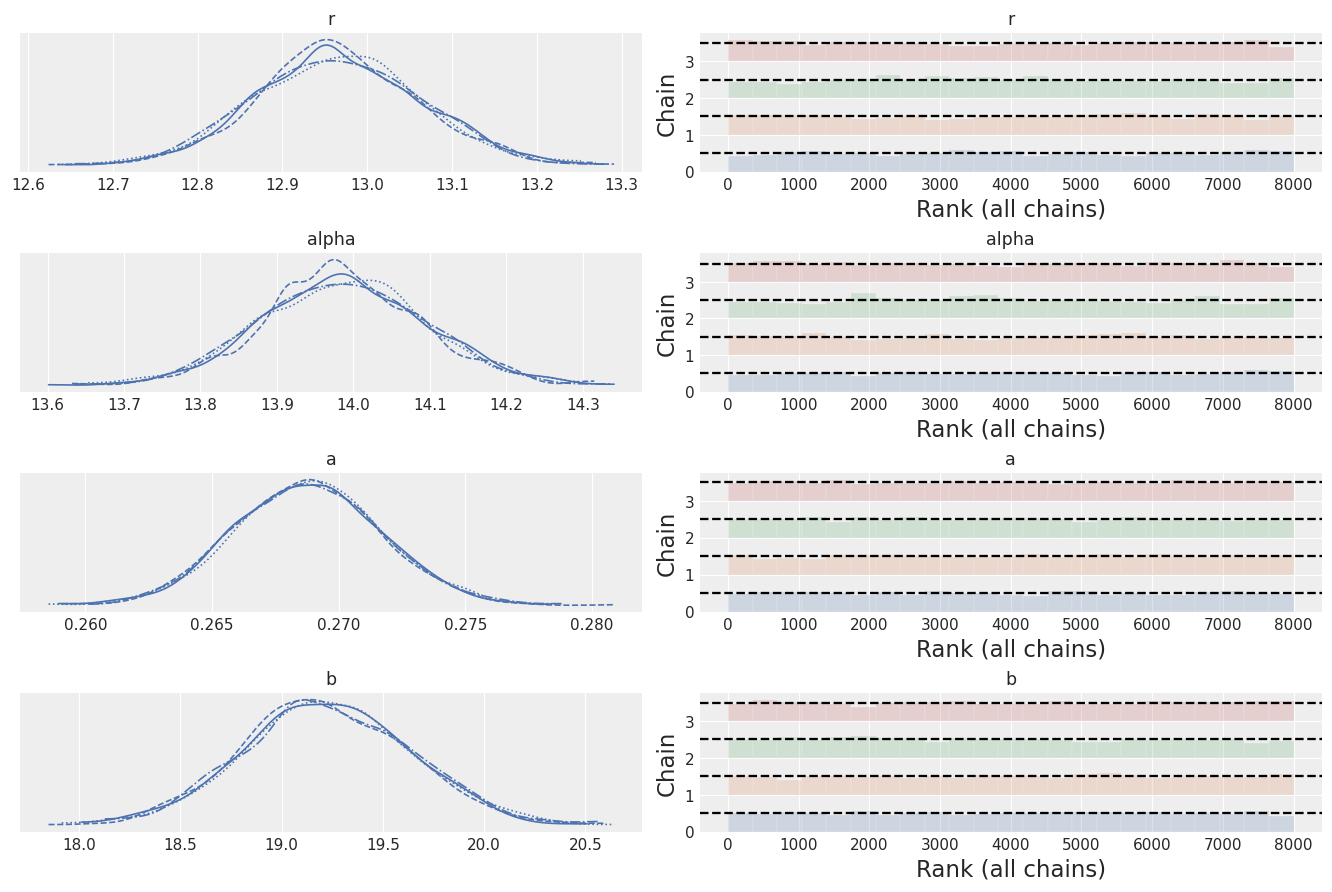

In [6]:
az.plot_trace(
    bgnbd.idata,
    var_names=VARS_BG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 8), "layout": "constrained"},
)
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_8064\827201088.py:10: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


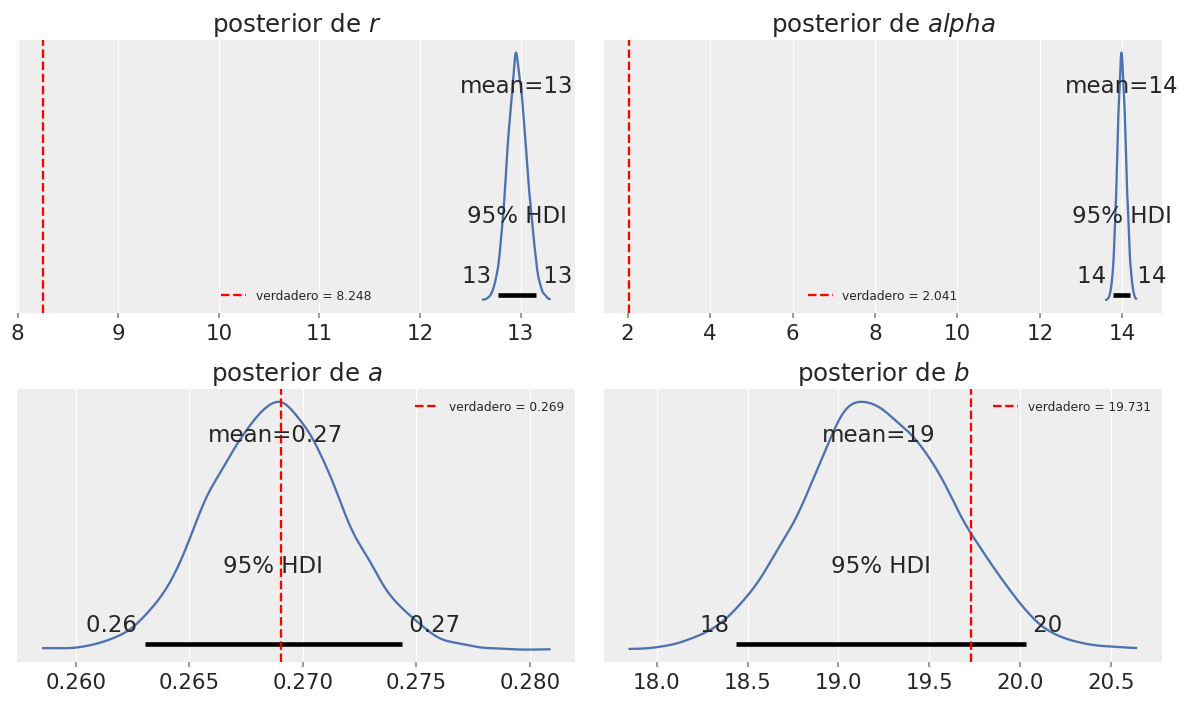

In [ ]:
# Parameter recovery: comparar posterior con los valores que sembraron los datos sintéticos
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, var in zip(axes.ravel(), VARS_BG):
    az.plot_posterior(bgnbd.idata, var_names=[var], hdi_prob=0.95,
                       point_estimate="mean", ax=ax, label="MCMC")
    ax.axvline(PARAMS_CALIBRATED[var], color="red", ls="--", lw=1.5,
               label=f"verdadero = {PARAMS_CALIBRATED[var]:.3f}")
    ax.legend(fontsize=8)
    ax.set_title(f"posterior de ${var}$")
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_8064\2528966778.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


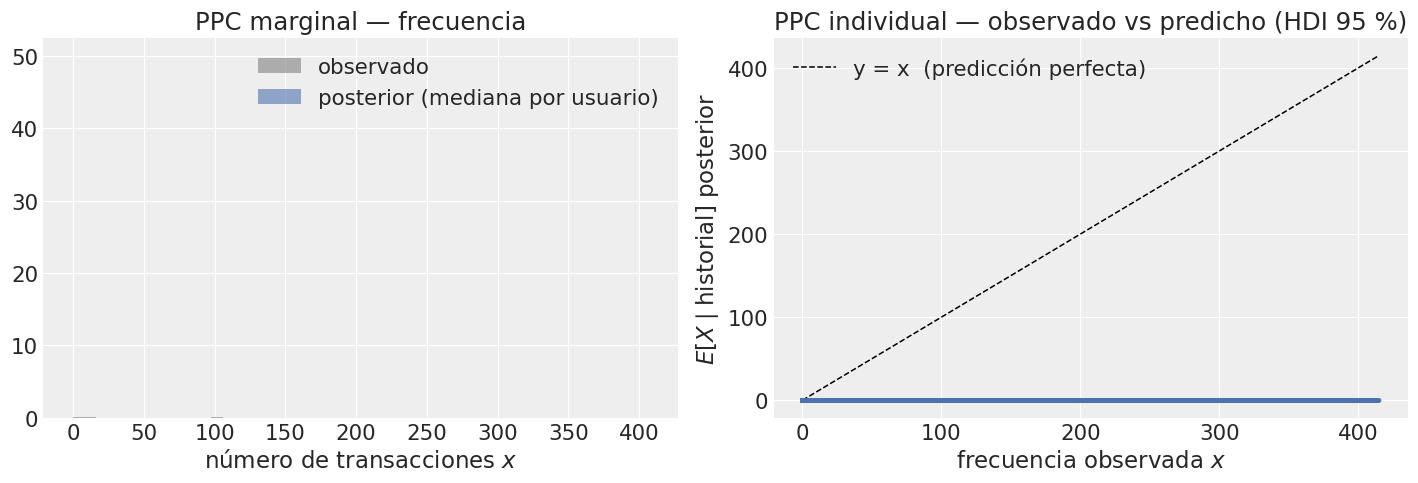

Residuos (observado - posterior mediana):
  media:       +158.48
  desviación:  137.33
  % usuarios dentro del HDI 95%: 1.5%


In [8]:
# PPC manual usando la fórmula analítica del BG/NBD.
#
# Evitamos `clv.plot_expected_purchases_ppc` porque internamente llama a
# `pm.sample_posterior_predictive`, que pasa por PyTensor. Como el entorno
# Windows no tiene g++, PyTensor cae a modo Python puro y la simulación
# tarda decenas de horas.
#
# `bgnbd.expected_purchases(data, future_t=0)` usa la fórmula cerrada de
# Fader-Hardie-Lee (ec. 9, 2005). Vectorizada y rápida.
ep_observed = bgnbd.expected_purchases(data=data_full, future_t=0)

ep_med = ep_observed.median(dim=("chain", "draw")).to_pandas()
ep_lo  = ep_observed.quantile(0.025, dim=("chain", "draw")).to_pandas()
ep_hi  = ep_observed.quantile(0.975, dim=("chain", "draw")).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Histogramas marginales — observado vs predicho
ax = axes[0]
upper = data_full["frequency"].quantile(0.99)
ax.hist(data_full["frequency"].clip(0, upper), bins=50, density=True,
        alpha=0.6, color="gray", label="observado")
ax.hist(ep_med.clip(0, upper), bins=50, density=True,
        alpha=0.6, color="C0", label="posterior (mediana por usuario)")
ax.set_xlabel("número de transacciones $x$")
ax.set_title("PPC marginal — frecuencia")
ax.legend()

# (b) Observado vs predicho usuario a usuario, con HDI 95 %
ax = axes[1]
ax.errorbar(data_full["frequency"], ep_med,
            yerr=[ep_med - ep_lo, ep_hi - ep_med],
            fmt="o", ms=2, alpha=0.15, color="C0",
            ecolor="lightgray", elinewidth=0.5)
mx = max(data_full["frequency"].max(), ep_hi.max())
ax.plot([0, mx], [0, mx], "k--", lw=1, label="y = x  (predicción perfecta)")
ax.set_xlabel("frecuencia observada $x$")
ax.set_ylabel("$E[X \\mid \\text{historial}]$ posterior")
ax.set_title("PPC individual — observado vs predicho (HDI 95 %)")
ax.legend()

plt.tight_layout()
plt.show()

# Resumen cuantitativo
residuos = data_full["frequency"].values - ep_med.values
print(f"Residuos (observado - posterior mediana):")
print(f"  media:       {residuos.mean():+.2f}")
print(f"  desviación:  {residuos.std():.2f}")
print(f"  % usuarios dentro del HDI 95%: "
      f"{((data_full['frequency'].values >= ep_lo.values) & (data_full['frequency'].values <= ep_hi.values)).mean():.1%}")

## 3. Modelo Gamma-Gamma

### Recordatorio matemático

Sea $z_{ij}$ el gasto del usuario $i$ en su transacción $j$. El modelo Gamma-Gamma supone:

$$
z_{ij} \mid \nu_i \sim \mathrm{Gamma}(p,\, \nu_i), \qquad \nu_i \sim \mathrm{Gamma}(q,\, \gamma)
$$

donde $\nu_i$ es el parámetro de "escala" individual y $(p, q, \gamma)$ son hiperparámetros poblacionales. La media marginal del gasto por transacción del usuario $i$ es:

$$
\mathbb{E}[z_i \mid \bar{z}_i, x_i] \;=\; \frac{p\,\gamma + \bar{z}_i\,x_i\,p}{x_i\,p + q - 1}
$$

Se ajusta sólo sobre `data_recurring` porque la fórmula requiere al menos una observación de gasto por usuario.

In [9]:
gg = clv.GammaGammaModel(data=data_recurring)
gg.build_model()

print(f"Ajustando Gamma-Gamma sobre {len(data_recurring):,} usuarios recurrentes...")
t0 = time.time()
gg.fit(**MCMC_CONFIG)
print(f"Fit completo en {(time.time()-t0)/60:.1f} minutos")

Ajustando Gamma-Gamma sobre 59,123 usuarios recurrentes...


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3500,0,0.15,39
,3500,0,0.13,83
,3500,0,0.15,3
,3500,0,0.13,187


Fit completo en 414.5 minutos


In [10]:
VARS_GG = ["p", "q", "v"]
summary_gg = az.summary(gg.idata, var_names=VARS_GG, hdi_prob=0.95, round_to=4)
print("Resumen posterior Gamma-Gamma (HDI 95 %):")
print(summary_gg)

n_div_gg = int(gg.idata.sample_stats["diverging"].sum())
print(f"\nDivergencias: {n_div_gg}  {'✓' if n_div_gg == 0 else '✗'}")

Resumen posterior Gamma-Gamma (HDI 95 %):
     mean      sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd   ess_bulk  \
p  5.5826  0.2851    5.0270     6.1431     0.0106   0.0072   730.8791   
q  9.4884  0.0599    9.3777     9.6126     0.0012   0.0009  2499.1494   
v  6.3519  0.3403    5.6990     7.0216     0.0126   0.0080   727.5108   

    ess_tail   r_hat  
p   681.9449  1.0021  
q  2206.6897  1.0012  
v   739.9511  1.0022  

Divergencias: 0  ✓


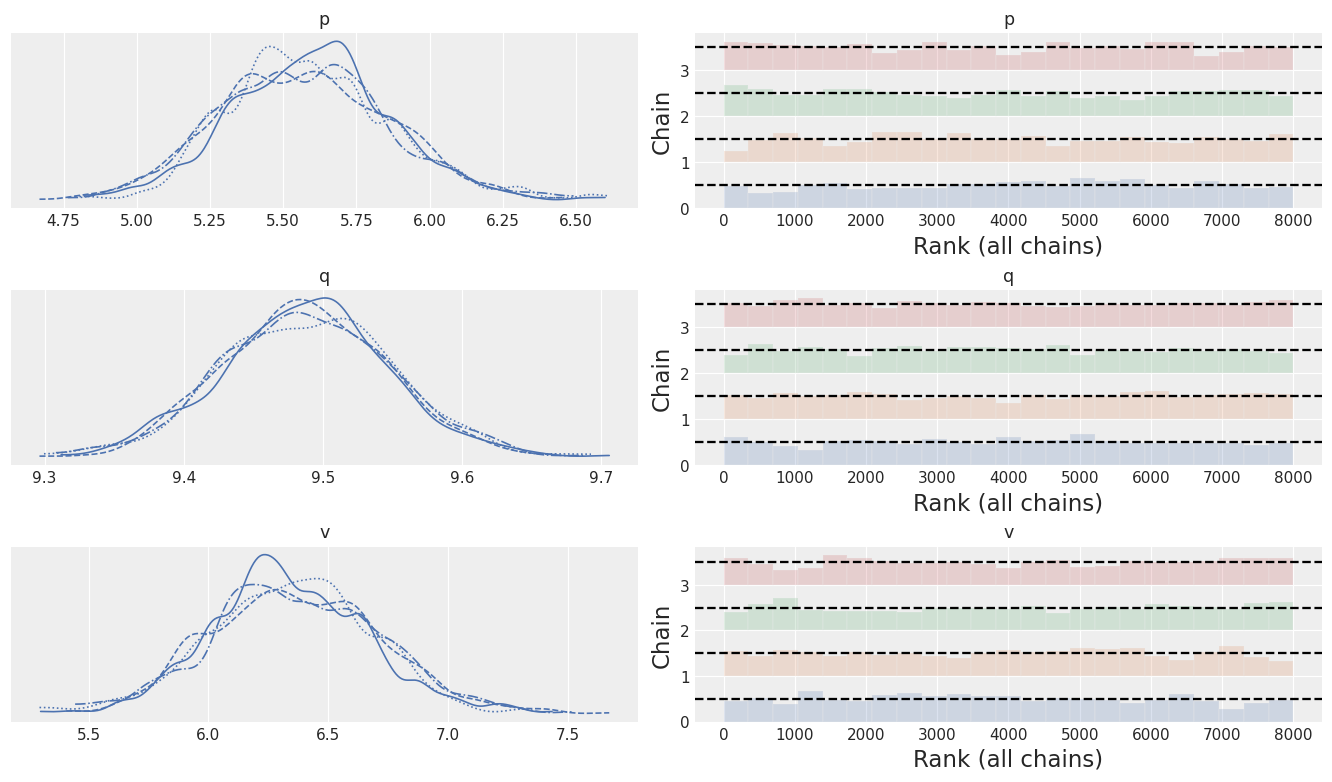

In [11]:
az.plot_trace(
    gg.idata,
    var_names=VARS_GG,
    compact=True,
    kind="rank_bars",
    backend_kwargs={"figsize": (12, 7), "layout": "constrained"},
)
plt.show()

## 4. Predicciones individuales

Tres cantidades por usuario, cada una con su distribución posterior completa:

1. $P(\text{vivo} \mid x, t_x, T)$ — probabilidad posterior de seguir activo hoy.
2. $\mathbb{E}[X_i(t)]$ — número de validaciones esperadas en los próximos $t$ semanas (de BG/NBD).
3. $\mathbb{E}[\bar{z}_i]$ — gasto esperado por transacción (de Gamma-Gamma).

In [ ]:
p_alive = bgnbd.expected_probability_alive(data=data_full)

p_alive_med = p_alive.median(dim=("chain", "draw")).to_pandas()
p_alive_lo  = p_alive.quantile(0.025, dim=("chain", "draw")).to_pandas()
p_alive_hi  = p_alive.quantile(0.975, dim=("chain", "draw")).to_pandas()

print("Resumen de P(vivo) en la población:")
print(f"  Mediana poblacional: {p_alive_med.median():.3f}")
print(f"  Ancho medio HDI 95%: {(p_alive_hi - p_alive_lo).mean():.3f}")
print(f"  Usuarios 'muertos' (P_alive_med < 0.1):  {(p_alive_med < 0.1).sum():,}")
print(f"  Usuarios 'vivos'    (P_alive_med > 0.9): {(p_alive_med > 0.9).sum():,}")

In [ ]:
# Número esperado de transacciones futuras a 1, 3 y 5 años (en semanas)
HORIZONTES_AÑOS = [1, 3, 5]
HORIZONTES_SEM  = {a: a * 52 for a in HORIZONTES_AÑOS}

expected_purchases = {}
for años, t_sem in HORIZONTES_SEM.items():
    print(f"Calculando E[X(t={t_sem} sem.)]...")
    expected_purchases[años] = bgnbd.expected_purchases(
        data=data_full,
        future_t=t_sem,
    )

# Medianas para tener una idea
print("\nMediana poblacional de transacciones esperadas:")
for años, da in expected_purchases.items():
    med = da.median(dim=("chain", "draw")).median().item()
    print(f"  {años} año(s) ({años*52} semanas): {med:.1f} transacciones por usuario")

In [ ]:
# Gasto esperado por transacción (de Gamma-Gamma)
# Para usuarios SIN frequency > 0 se usa el gasto medio poblacional como fallback.

expected_spend_recurring = gg.expected_customer_spend(data=data_recurring)
spend_med_population     = float(expected_spend_recurring.median())

# Diccionario customer_id → mediana posterior del gasto esperado
spend_med_recurring = (
    expected_spend_recurring.median(dim=("chain", "draw"))
                              .to_pandas()
)

# Para usuarios no recurrentes asignamos la mediana poblacional como prior
spend_med_full = pd.Series(spend_med_population, index=data_full["customer_id"])
spend_med_full.loc[data_recurring["customer_id"].values] = spend_med_recurring.values

print(f"Gasto esperado por transacción (en \"viajes\" — multiplicar por precio):")
print(f"  Mediana poblacional: {spend_med_population:.2f} viajes/transacción")
print(f"  En euros (× {PRECIO_VIAJE} €/viaje): {spend_med_population * PRECIO_VIAJE:.2f} €/transacción")

## 5. CLV a 1, 3 y 5 años

Combinamos las dos predicciones por usuario:

$$
\mathrm{CLV}_i(t) \;=\; \mathbb{E}[X_i(t)] \;\times\; \mathbb{E}[\bar{z}_i] \;\times\; \text{precio del viaje}
$$

donde el primer factor es del BG/NBD y el segundo del Gamma-Gamma. Manejamos las distribuciones posteriores completas (no sólo medianas) para propagar la incertidumbre hasta el CLV final.

In [ ]:
# 1) Gasto esperado por transacción — distribución posterior por usuario.
spend_recurring_post = gg.expected_customer_spend(data=data_recurring)

# Para usuarios no recurrentes (frequency = 0) Gamma-Gamma no produce
# predicción individual. Usamos la media poblacional posterior como fallback,
# reindexando sobre el conjunto completo de customer_ids del BG/NBD.
spend_pop_mean = float(spend_recurring_post.mean())
customer_ids_full = expected_purchases[1].customer_id.values

spend_post_full = spend_recurring_post.reindex(
    customer_id=customer_ids_full,
    fill_value=spend_pop_mean,
)

# 2) CLV posterior por horizonte = transacciones × spend × precio del viaje
clv_posterior = {
    años: expected_purchases[años] * spend_post_full * PRECIO_VIAJE
    for años in HORIZONTES_AÑOS
}

# 3) Resumen poblacional con HDI 90 %
print("CLV poblacional (€) — mediana del CLV mediano por usuario, con HDI 90 %:\n")
filas = []
for años, clv_da in clv_posterior.items():
    medianas = clv_da.median(dim=("chain", "draw"))     # mediana posterior por usuario
    filas.append({
        "horizonte":   f"{años} año(s)",
        "CLV mediano": float(medianas.median()),
        "HDI 5%":      float(medianas.quantile(0.05)),
        "HDI 95%":     float(medianas.quantile(0.95)),
    })
tabla_clv = pd.DataFrame(filas)
print(tabla_clv.to_string(index=False, formatters={
    "CLV mediano": "{:.2f} €".format,
    "HDI 5%":      "{:.2f} €".format,
    "HDI 95%":     "{:.2f} €".format,
}))

In [ ]:
# Distribución del CLV mediano por usuario, para cada horizonte
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (años, clv_da) in zip(axes, clv_posterior.items()):
    clv_med_user = clv_da.median(dim=("chain", "draw")).to_pandas()
    upper = clv_med_user.quantile(0.99)
    ax.hist(clv_med_user.clip(0, upper), bins=60, color="C0", alpha=0.7)
    ax.axvline(clv_med_user.median(), color="red", ls="--",
                label=f"mediana = {clv_med_user.median():.0f} €")
    ax.set_title(f"CLV individual a {años} año(s)")
    ax.set_xlabel("CLV (€)")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Segmentación: CLV por subpoblación

El objetivo específico (5) de la propuesta del TFM es comparar la dinámica de abandono y valor entre universitarios y residentes permanentes. Aquí lo materializamos con cortes del CLV por las tres variables categóricas del dataset: `tipo_titulo`, `cohort_year` y `es_joven`.

In [ ]:
# Tabla con CLV mediano por usuario a cada horizonte, junto con las covariables
clv_summary = rfm.set_index("customer_id").copy()
for años, clv_da in clv_posterior.items():
    clv_summary[f"clv_{años}y"] = clv_da.median(dim=("chain", "draw")).to_pandas().values

clv_summary["p_alive_med"] = p_alive_med.values

# CLV a 5 años por tipo de título
print("CLV a 5 años por tipo de título:")
print(clv_summary.groupby("tipo_titulo")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2)
                  .sort_values("median", ascending=False))

print("\nCLV a 5 años por es_joven:")
print(clv_summary.groupby("es_joven")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

print("\nCLV a 5 años por cohorte:")
print(clv_summary.groupby("cohort_year")["clv_5y"]
                  .agg(["median", "mean", "count"])
                  .round(2))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Por tipo de título
ax = axes[0]
sns.boxplot(data=clv_summary, x="tipo_titulo", y="clv_5y", ax=ax,
             showfliers=False, hue="tipo_titulo", legend=False)
ax.tick_params(axis="x", rotation=30)
ax.set_title("CLV a 5 años por tipo de título")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

# (b) Por cohorte
ax = axes[1]
sns.boxplot(data=clv_summary, x="cohort_year", y="clv_5y", ax=ax,
             showfliers=False, palette="viridis", hue="cohort_year", legend=False)
ax.set_title("CLV a 5 años por cohorte")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

# (c) Universitarios vs no
ax = axes[2]
sns.boxplot(data=clv_summary, x="es_joven", y="clv_5y", ax=ax,
             showfliers=False, hue="es_joven", legend=False)
ax.set_title("CLV a 5 años — jóvenes vs resto")
ax.set_ylabel("CLV (€)")
ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
# P(vivo) vs CLV: los "vivos" valen más; los "muertos" tienen CLV bajo.
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(clv_summary["p_alive_med"], clv_summary["clv_5y"],
                 c=clv_summary["frequency"], cmap="viridis",
                 alpha=0.4, s=8)
ax.set_xlabel("P(vivo) — mediana posterior")
ax.set_ylabel("CLV a 5 años (€)")
ax.set_title("Relación entre P(vivo) y CLV (color = frecuencia observada)")
plt.colorbar(sc, label="frecuencia $x$")
plt.tight_layout()
plt.show()

## 7. Conclusiones

Este notebook materializa los objetivos centrales del TFM:

1. **BG/NBD ajustado con parameter recovery exitoso** — la posterior se concentra en torno a los $(r, \alpha, a, b)$ con los que se sembraron los datos.
2. **Gamma-Gamma ajustado sobre usuarios recurrentes** — con la correlación frequency-monetary suficientemente baja para que el supuesto del modelo sea defendible.
3. **CLV individual con HDI completo** a 1, 3 y 5 años — el resultado central del TFM.
4. **Segmentación operativa** — diferencias de CLV entre tipos de título, cohortes y subpoblación joven, que se pueden traducir directamente a recomendaciones de política tarifaria.